# Run noise analysis

In [1]:
import os
from pathlib import Path
from dna_linker import dna_linkers as dnal
from dna_linker import run_pipeline as run
from dna_linker import config
from cryocat import cryomotl
import numpy as np
import pandas as pd

# Functions

In [3]:
def connectivity_to_edge_set(conn_dict):
    """
    Converts a connectivity dictionary of the form
      {node: [(neighbor, prob, type), ...], ...}
    into a set of undirected edges (node1, node2, type) with node1 < node2.
    """
    edges = set()
    for node, neighbors in conn_dict.items():
        for neighbor, _, edge_type in neighbors:
            i, j = sorted((node, neighbor))
            edges.add((i, j, edge_type))
    return edges


def compute_f1_from_connectivity(truth_conn, pred_conn):
    """
    Computes precision, recall, and F1-score between ground-truth
    and predicted connectivity dictionaries.

    Parameters:
        truth_conn (dict): Ground truth connectivity:
            {node: [(neighbor, prob, type), ...], ...}
        pred_conn (dict): Predicted connectivity, same format.

    Returns:
        precision (float), recall (float), f1_score (float)
    """
    # Convert both to undirected edge-sets
    truth_edges = connectivity_to_edge_set(truth_conn)
    pred_edges = connectivity_to_edge_set(pred_conn)

    # True Positives, False Positives, False Negatives
    tp = len(truth_edges & pred_edges)
    fp = len(pred_edges - truth_edges)
    fn = len(truth_edges - pred_edges)

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall    = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1        = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0

    return precision, recall, f1


def add_noise_to_motl(
    motl: cryomotl.Motl,
    pos_sigma: float,
    ang_sigma_deg: float,
    output_filename:str,
    seed: int = None
) -> cryomotl.Motl:
    """
    Returns a copy of `motl` where each particle has independent Gaussian
    noise added to (x,y,z) and (phi,psi,theta).

    Parameters:
        motl: a cryomotl.Motl instance.
        pos_sigma: standard deviation for positional noise (same units as x,y,z).
        ang_sigma_deg: standard deviation for angular noise (degrees).
        seed: optional random seed.

    Returns:
        new_motl: a fresh cryomotl.Motl with motl.df modified.
    """
    df = motl.df.copy()
    rng = np.random.default_rng(seed)

    # add to x,y,z shifts
    for coord in ("x", "y", "z"):
        df[coord] = df[coord] + rng.normal(0, pos_sigma, size=len(df))
    # add to Euler angles
    for ang in ("phi", "psi", "theta"):
        df[ang] = df[ang] + rng.normal(0, ang_sigma_deg, size=len(df))

    # create a new EmMotl object from this DF
    new = cryomotl.Motl(motl_df=df)
    new.write_out(output_filename)
    return new, output_filename


# Paths

In [4]:
# Fixed inputs
path_mask = './inputs_noisy/'
#path_mask = './inputs/'
entry = 'Threshold_ref_entrymask_r2_resamp_righthand.mrc'
exit = 'Threshold_ref_exitmask_r2_resamp_righthand.mrc'
origin_entry = 'Threshold_ref_Origin_entrymask_r2_resamp_righthand.mrc'
origin_exit = 'Threshold_ref_Origin_exitmask_r2_resamp_righthand.mrc'

# Global config
tracing_distance=config.tracing_distance # Extenrnal user parameter - Distance
pixel_size = config.pixel_size # Models are at in the right scale
bin=config.bin
max_distance=tracing_distance/(pixel_size*bin)



# Run noise analysis - position

In [5]:
%%time
from pathlib import Path
from tqdm.auto import tqdm

# -------------------------------------------
# 1.  EXPERIMENT SETTINGS
# -------------------------------------------
N_TRIALS      = 50
POS_SIGMAS    = np.array([1, 3, 5, 10, 15, 20, 25, 30])   # 0 Å left out on purpose
ANG_SIGMA_DEG = 0
EMD_ID        = 2601                                      # only one map for now

# -------------------------------------------
# 2.  STATIC FILES & CONSTANTS
# -------------------------------------------
GT_PATH = (
    './outputs/outputs_EMD2601_STA_tmpl/'
    'A_Connections_dictionary_20nm/'
    'Connectivity_motl_tomo0.0_cluster12.0.pickle'
)
GT_DICT = pd.read_pickle(GT_PATH)                         # read **once**

# where to collect numbers ↓
records = []

# -------------------------------------------
# 3.  SWEEP OVER NOISE LEVELS
# -------------------------------------------
for pos_sigma in tqdm(POS_SIGMAS, desc='σ translational noise (Å)'):
    # fresh containers for this σ if you still need them later
    f1_list, prec_list, rec_list = [], [], []

    for trial in tqdm(range(N_TRIALS),
                      desc=f'{pos_sigma:>2} Å trials',
                      leave=False):
        # 3-a) Generate a noisy motive-list -----------------------------
        suffix = f'noisePos_{pos_sigma}_noiseAng_{ANG_SIGMA_DEG}'
        add_noise_to_motl(
            motl=cryomotl.EmMotl('inputs/motl_EMD2601_STA_tmpl.em'),
            pos_sigma=pos_sigma,
            ang_sigma_deg=ANG_SIGMA_DEG,
            output_filename=f'inputs_noisy/motl_EMD{EMD_ID}_{suffix}.em'
        )

        # 3-b) Build paths ---------------------------------------------
        motl_name = f'motl_EMD{EMD_ID}_{suffix}.em'
        path_output = f'./out_tracing/EMD{EMD_ID}_{suffix}/'
        motl_trace_input = path_output + f'EMD{EMD_ID}_tr{int(tracing_distance)}nm_{suffix}.em'

        output_path_cluster     = f'./outputs/outputs_EMD{EMD_ID}_{suffix}/clusters_20nm/'
        output_path_linker      = f'./outputs/outputs_EMD{EMD_ID}_{suffix}/A_linkers_20nm/'
        output_path_dictionary  = f'./outputs/outputs_EMD{EMD_ID}_{suffix}/A_Connections_dictionary_20nm/'

        for p in [path_output, output_path_cluster,
                  output_path_linker, output_path_dictionary]:
            Path(p).mkdir(parents=True, exist_ok=True)

        # 3-c) Run the pipeline ----------------------------------------
        run.run_full_pipeline(
            path_mask=path_mask,
            motl_name=motl_name,
            entry=entry,
            exit=exit,
            origin_entry=origin_entry,
            origin_exit=origin_exit,
            path_output=path_output,
            motl_trace_input=motl_trace_input,
            tracing_distance=tracing_distance,
            max_distance=max_distance,
            output_path_cluster=output_path_cluster,
            output_path_linker=output_path_linker,
            output_path_dictionary=output_path_dictionary,
            dnal_object=dnal.lo,
            max_processes=8
        )

        # 3-d) Metrics -------------------------------------------------
        pred_path = (
            f'./outputs/outputs_EMD{EMD_ID}_{suffix}/'
            'A_Connections_dictionary_20nm/'
            'Connectivity_motl_tomo0.0_cluster12.0.pickle'
        )
        pred_dict = pd.read_pickle(pred_path)

        prec, rec, f1 = compute_f1_from_connectivity(GT_DICT, pred_dict)

        # keep per-σ lists (optional)
        f1_list  .append(f1)
        prec_list.append(prec)
        rec_list .append(rec)

        # flat record for DataFrame
        records.append({
            'sigma': pos_sigma,
            'trial': trial,
            'precision': prec,
            'recall'   : rec,
            'f1'       : f1
        })

    # END inner loop over trials
# END outer loop over σ

# -------------------------------------------
# 4.  SAVE EVERYTHING TO DISK
# -------------------------------------------
df = pd.DataFrame(records)
df.to_pickle('noise_sweep_metrics.pkl')       # **full fidelity**
df.to_csv   ('noise_sweep_metrics.csv', index=False)

# save also as NumPy arrays (shape: [σ, trials])
pivot = (
    df.pivot(index='sigma', columns='trial', values=['precision', 'recall', 'f1'])
      .sort_index()
      .to_numpy()
)
np.savez(
    'noise_sweep_metrics.npz',
    pos_sigmas = POS_SIGMAS,
    precision  = pivot[0],   # precision matrix
    recall     = pivot[1],   # recall    "
    f1         = pivot[2]    # f1        "
)

print(' Results written to noise_sweep_metrics.(pkl | csv | npz)')


σ translational noise (Å):   0%|          | 0/8 [00:00<?, ?it/s]

 1 Å trials:   0%|          | 0/50 [00:00<?, ?it/s]

The file:  ./outputs/outputs_EMD2601_noisePos_1_noiseAng_0/clusters_20nm/motl_tomo0.0_cluster12.0.em has been saved!
Tomogram: 0.0
Tomogram: 0.0, and cluster 12.0
Figure(640x480)
(12, 12, 4)
Largest connected component: {0, 2, 3, 4, 5, 6, 7, 8, 10, 11}
Size of largest connected component: 10
{0, 2, 3, 4, 5, 6, 7, 8, 10, 11}
Figure(640x480)
The file:  ./outputs/outputs_EMD2601_noisePos_1_noiseAng_0/clusters_20nm/motl_tomo0.0_cluster12.0.em has been saved!
Tomogram: 0.0
Tomogram: 0.0, and cluster 12.0
Figure(640x480)
(12, 12, 4)
Largest connected component: {0, 2, 3, 4, 5, 6, 7, 8, 10, 11}
Size of largest connected component: 10
{0, 2, 3, 4, 5, 6, 7, 8, 10, 11}
Figure(640x480)
The file:  ./outputs/outputs_EMD2601_noisePos_1_noiseAng_0/clusters_20nm/motl_tomo0.0_cluster12.0.em has been saved!
Tomogram: 0.0
Tomogram: 0.0, and cluster 12.0
Figure(640x480)
(12, 12, 4)
Largest connected component: {0, 2, 4, 5, 6, 8, 10, 11}
Size of largest connected component: 8
{0, 2, 4, 5, 6, 8, 10, 11}
Fig

 3 Å trials:   0%|          | 0/50 [00:00<?, ?it/s]

The file:  ./outputs/outputs_EMD2601_noisePos_3_noiseAng_0/clusters_20nm/motl_tomo0.0_cluster12.0.em has been saved!
Tomogram: 0.0
Tomogram: 0.0, and cluster 12.0
Figure(640x480)
(12, 12, 4)
Largest connected component: {0, 2, 3, 4, 5, 6, 7, 8, 10, 11}
Size of largest connected component: 10
{0, 2, 3, 4, 5, 6, 7, 8, 10, 11}
Figure(640x480)
The file:  ./outputs/outputs_EMD2601_noisePos_3_noiseAng_0/clusters_20nm/motl_tomo0.0_cluster12.0.em has been saved!
Tomogram: 0.0
Tomogram: 0.0, and cluster 12.0
Figure(640x480)
(12, 12, 4)
Largest connected component: {0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11}
Size of largest connected component: 12
{0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11}
Figure(640x480)
The file:  ./outputs/outputs_EMD2601_noisePos_3_noiseAng_0/clusters_20nm/motl_tomo0.0_cluster12.0.em has been saved!
Tomogram: 0.0
Tomogram: 0.0, and cluster 12.0
Figure(640x480)
(12, 12, 4)
Largest connected component: {0, 2, 3, 4, 5, 6, 7, 8, 10, 11}
Size of largest connected component: 10
{0, 2, 3, 4

...

The file:  ./outputs/outputs_EMD2601_noisePos_20_noiseAng_0/clusters_20nm/motl_tomo0.0_cluster12.0.em has been saved!
Tomogram: 0.0
Tomogram: 0.0, and cluster 12.0
Figure(640x480)
(12, 12, 4)
Largest connected component: {8, 4, 6}
Size of largest connected component: 3
{8, 4, 6}
Figure(640x480)
The file:  ./outputs/outputs_EMD2601_noisePos_20_noiseAng_0/clusters_20nm/motl_tomo0.0_cluster12.0.em has been saved!
Tomogram: 0.0
Tomogram: 0.0, and cluster 12.0
Figure(640x480)
(12, 12, 4)
Largest connected component: {3, 4, 5, 6, 7}
Size of largest connected component: 5
{3, 4, 5, 6, 7}
Figure(640x480)
The file:  ./outputs/outputs_EMD2601_noisePos_20_noiseAng_0/clusters_20nm/motl_tomo0.0_cluster12.0.em has been saved!
Tomogram: 0.0
Tomogram: 0.0, and cluster 12.0
Figure(640x480)
(12, 12, 4)
Largest connected component: {8, 1, 4, 6}
Size of largest connected component: 4
{8, 1, 4, 6}
Figure(640x480)
The file:  ./outputs/outputs_EMD2601_noisePos_20_noiseAng_0/clusters_20nm/motl_tomo0.0_cluster

25 Å trials:   0%|          | 0/50 [00:00<?, ?it/s]

The file:  ./outputs/outputs_EMD2601_noisePos_25_noiseAng_0/clusters_20nm/motl_tomo0.0_cluster12.0.em has been saved!
Tomogram: 0.0
Tomogram: 0.0, and cluster 12.0
Figure(640x480)
(12, 12, 4)
Largest connected component: {0, 9, 11}
Size of largest connected component: 3
{0, 9, 11}
Figure(640x480)
The file:  ./outputs/outputs_EMD2601_noisePos_25_noiseAng_0/clusters_20nm/motl_tomo0.0_cluster12.0.em has been saved!
Tomogram: 0.0
Tomogram: 0.0, and cluster 12.0
Figure(640x480)
(12, 12, 4)
Largest connected component: {4, 5, 6}
Size of largest connected component: 3
{4, 5, 6}
Figure(640x480)
The file:  ./outputs/outputs_EMD2601_noisePos_25_noiseAng_0/clusters_20nm/motl_tomo0.0_cluster12.0.em has been saved!
Tomogram: 0.0
Tomogram: 0.0, and cluster 12.0
Figure(640x480)
(12, 12, 4)
Largest connected component: {1, 2, 5, 7, 10}
Size of largest connected component: 5
{1, 2, 5, 7, 10}
Figure(640x480)
The file:  ./outputs/outputs_EMD2601_noisePos_25_noiseAng_0/clusters_20nm/motl_tomo0.0_cluster12

30 Å trials:   0%|          | 0/50 [00:00<?, ?it/s]

The file:  ./outputs/outputs_EMD2601_noisePos_30_noiseAng_0/clusters_20nm/motl_tomo0.0_cluster12.0.em has been saved!
Tomogram: 0.0
Tomogram: 0.0, and cluster 12.0
Figure(640x480)
(12, 12, 4)
Largest connected component: {1, 4, 5, 6, 8, 11}
Size of largest connected component: 6
{1, 4, 5, 6, 8, 11}
Figure(640x480)
The file:  ./outputs/outputs_EMD2601_noisePos_30_noiseAng_0/clusters_20nm/motl_tomo0.0_cluster12.0.em has been saved!
Tomogram: 0.0
Tomogram: 0.0, and cluster 12.0
Figure(640x480)
(12, 12, 4)
Largest connected component: {8, 3, 6}
Size of largest connected component: 3
{8, 3, 6}
Figure(640x480)
The file:  ./outputs/outputs_EMD2601_noisePos_30_noiseAng_0/clusters_20nm/motl_tomo0.0_cluster12.0.em has been saved!
Tomogram: 0.0
Tomogram: 0.0, and cluster 12.0
Figure(640x480)
(12, 12, 4)
Largest connected component: {0, 1, 10}
Size of largest connected component: 3
{0, 1, 10}
Figure(640x480)
The file:  ./outputs/outputs_EMD2601_noisePos_30_noiseAng_0/clusters_20nm/motl_tomo0.0_clu

# Run noise analysis - angles

In [8]:
%%time
from pathlib import Path
from tqdm.auto import tqdm

# -------------------------------------------
# 1.  EXPERIMENT SETTINGS
# -------------------------------------------
N_TRIALS      = 50
POS_SIGMAS    = 0  # 0 Å left out on purpose
ANG_SIGMA_DEG = np.array([1, 3, 5, 10, 15, 20, 25, 30]) # deg
EMD_ID        = 2601                                      # only one map for now

# -------------------------------------------
# 2.  STATIC FILES & CONSTANTS
# -------------------------------------------
GT_PATH = (
    './outputs/outputs_EMD2601_STA_tmpl/'
    'A_Connections_dictionary_20nm/'
    'Connectivity_motl_tomo0.0_cluster12.0.pickle'
)
GT_DICT = pd.read_pickle(GT_PATH)                         # read **once**

# where to collect numbers ↓
records = []

# -------------------------------------------
# 3.  SWEEP OVER NOISE LEVELS
# -------------------------------------------
for ang_sigma in tqdm(ANG_SIGMA_DEG, desc='σ rotational noise (Å)'):
    # fresh containers for this σ if you still need them later
    f1_list, prec_list, rec_list = [], [], []

    for trial in tqdm(range(N_TRIALS),
                      desc=f'{ang_sigma:>2} Å trials',
                      leave=False):
        # 3-a) Generate a noisy motive-list -----------------------------
        suffix = f'noisePos_{POS_SIGMAS}_noiseAng_{ang_sigma}'
        add_noise_to_motl(
            motl=cryomotl.EmMotl('inputs/motl_EMD2601_STA_tmpl.em'),
            pos_sigma=POS_SIGMAS,
            ang_sigma_deg=ang_sigma,
            output_filename=f'inputs_noisy/motl_EMD{EMD_ID}_{suffix}.em'
        )

        # 3-b) Build paths ---------------------------------------------
        motl_name = f'motl_EMD{EMD_ID}_{suffix}.em'
        path_output = f'./out_tracing/EMD{EMD_ID}_{suffix}/'
        motl_trace_input = path_output + f'EMD{EMD_ID}_tr{int(tracing_distance)}nm_{suffix}.em'

        output_path_cluster     = f'./outputs/outputs_EMD{EMD_ID}_{suffix}/clusters_20nm/'
        output_path_linker      = f'./outputs/outputs_EMD{EMD_ID}_{suffix}/A_linkers_20nm/'
        output_path_dictionary  = f'./outputs/outputs_EMD{EMD_ID}_{suffix}/A_Connections_dictionary_20nm/'

        for p in [path_output, output_path_cluster,
                  output_path_linker, output_path_dictionary]:
            Path(p).mkdir(parents=True, exist_ok=True)

        # 3-c) Run the pipeline ----------------------------------------
        run.run_full_pipeline(
            path_mask=path_mask,
            motl_name=motl_name,
            entry=entry,
            exit=exit,
            origin_entry=origin_entry,
            origin_exit=origin_exit,
            path_output=path_output,
            motl_trace_input=motl_trace_input,
            tracing_distance=tracing_distance,
            max_distance=max_distance,
            output_path_cluster=output_path_cluster,
            output_path_linker=output_path_linker,
            output_path_dictionary=output_path_dictionary,
            dnal_object=dnal.lo,
            max_processes=8
        )

        # 3-d) Metrics -------------------------------------------------
        pred_path = (
            f'./outputs/outputs_EMD{EMD_ID}_{suffix}/'
            'A_Connections_dictionary_20nm/'
            'Connectivity_motl_tomo0.0_cluster12.0.pickle'
        )
        pred_dict = pd.read_pickle(pred_path)

        prec, rec, f1 = compute_f1_from_connectivity(GT_DICT, pred_dict)

        # keep per-σ lists (optional)
        f1_list  .append(f1)
        prec_list.append(prec)
        rec_list .append(rec)

        # flat record for DataFrame
        records.append({
            'sigma (deg)': ang_sigma,
            'trial': trial,
            'precision': prec,
            'recall'   : rec,
            'f1'       : f1
        })

    # END inner loop over trials
# END outer loop over σ

# -------------------------------------------
# 4.  SAVE EVERYTHING TO DISK
# -------------------------------------------
df = pd.DataFrame(records)
df.to_pickle('angle_noise_sweep_metrics.pkl')       # **full fidelity**
df.to_csv   ('angle_noise_sweep_metrics.csv', index=False)

# save also as NumPy arrays (shape: [σ, trials])
pivot = (
    df.pivot(index='sigma', columns='trial', values=['precision', 'recall', 'f1'])
      .sort_index()
      .to_numpy()
)
np.savez(
    'noise_sweep_metrics.npz',
    pos_sigmas = ANG_SIGMA_DEG,
    precision  = pivot[0],   # precision matrix
    recall     = pivot[1],   # recall    "
    f1         = pivot[2]    # f1        "
)

print(' Results written to noise_sweep_metrics.(pkl | csv | npz)')


σ rotational noise (Å):   0%|          | 0/8 [00:00<?, ?it/s]

 1 Å trials:   0%|          | 0/50 [00:00<?, ?it/s]

The file:  ./outputs/outputs_EMD2601_noisePos_0_noiseAng_1/clusters_20nm/motl_tomo0.0_cluster12.0.em has been saved!
Tomogram: 0.0
Tomogram: 0.0, and cluster 12.0
Figure(640x480)
(12, 12, 4)
Largest connected component: {0, 1, 2, 4, 5, 6, 8, 9, 10, 11}
Size of largest connected component: 10
{0, 1, 2, 4, 5, 6, 8, 9, 10, 11}
Figure(640x480)
The file:  ./outputs/outputs_EMD2601_noisePos_0_noiseAng_1/clusters_20nm/motl_tomo0.0_cluster12.0.em has been saved!
Tomogram: 0.0
Tomogram: 0.0, and cluster 12.0
Figure(640x480)
(12, 12, 4)
Largest connected component: {0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11}
Size of largest connected component: 12
{0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11}
Figure(640x480)
The file:  ./outputs/outputs_EMD2601_noisePos_0_noiseAng_1/clusters_20nm/motl_tomo0.0_cluster12.0.em has been saved!
Tomogram: 0.0
Tomogram: 0.0, and cluster 12.0
Figure(640x480)
(12, 12, 4)
Largest connected component: {0, 2, 3, 4, 5, 6, 7, 8, 10, 11}
Size of largest connected component: 10
{0, 2, 3, 4

 3 Å trials:   0%|          | 0/50 [00:00<?, ?it/s]

The file:  ./outputs/outputs_EMD2601_noisePos_0_noiseAng_3/clusters_20nm/motl_tomo0.0_cluster12.0.em has been saved!
Tomogram: 0.0
Tomogram: 0.0, and cluster 12.0
Figure(640x480)
(12, 12, 4)
Largest connected component: {0, 1, 2, 4, 5, 6, 8, 9, 10, 11}
Size of largest connected component: 10
{0, 1, 2, 4, 5, 6, 8, 9, 10, 11}
Figure(640x480)
The file:  ./outputs/outputs_EMD2601_noisePos_0_noiseAng_3/clusters_20nm/motl_tomo0.0_cluster12.0.em has been saved!
Tomogram: 0.0
Tomogram: 0.0, and cluster 12.0
Figure(640x480)
(12, 12, 4)
Largest connected component: {0, 1, 2, 4, 5, 6, 8, 9, 10, 11}
Size of largest connected component: 10
{0, 1, 2, 4, 5, 6, 8, 9, 10, 11}
Figure(640x480)
The file:  ./outputs/outputs_EMD2601_noisePos_0_noiseAng_3/clusters_20nm/motl_tomo0.0_cluster12.0.em has been saved!
Tomogram: 0.0
Tomogram: 0.0, and cluster 12.0
Figure(640x480)
(12, 12, 4)
Largest connected component: {0, 1, 3, 4, 5, 6, 7, 8, 10, 11}
Size of largest connected component: 10
{0, 1, 3, 4, 5, 6, 7, 8

...

The file:  ./outputs/outputs_EMD2601_noisePos_0_noiseAng_25/clusters_20nm/motl_tomo0.0_cluster12.0.em has been saved!
Tomogram: 0.0
Tomogram: 0.0, and cluster 12.0
Figure(640x480)
(12, 12, 4)
Largest connected component: {2, 4, 5, 7}
Size of largest connected component: 4
{2, 4, 5, 7}
Figure(640x480)
The file:  ./outputs/outputs_EMD2601_noisePos_0_noiseAng_25/clusters_20nm/motl_tomo0.0_cluster12.0.em has been saved!
Tomogram: 0.0
Tomogram: 0.0, and cluster 12.0
Figure(640x480)
(12, 12, 4)
Largest connected component: {9, 2}
Size of largest connected component: 2
{9, 2}
Figure(640x480)
The file:  ./outputs/outputs_EMD2601_noisePos_0_noiseAng_25/clusters_20nm/motl_tomo0.0_cluster12.0.em has been saved!
Tomogram: 0.0
Tomogram: 0.0, and cluster 12.0
Figure(640x480)
(12, 12, 4)
Largest connected component: {0, 11}
Size of largest connected component: 2
{0, 11}
Figure(640x480)
The file:  ./outputs/outputs_EMD2601_noisePos_0_noiseAng_25/clusters_20nm/motl_tomo0.0_cluster12.0.em has been saved

30 Å trials:   0%|          | 0/50 [00:00<?, ?it/s]

The file:  ./outputs/outputs_EMD2601_noisePos_0_noiseAng_30/clusters_20nm/motl_tomo0.0_cluster9.0.em has been saved!
The file:  ./outputs/outputs_EMD2601_noisePos_0_noiseAng_30/clusters_20nm/motl_tomo0.0_cluster3.0.em has been saved!
Tomogram: 0.0
Tomogram: 0.0, and cluster 3.0
Figure(640x480)
(3, 3, 4)
0
Figure(640x480)
Tomogram: 0.0, and cluster 9.0
Figure(640x480)
(9, 9, 4)
Largest connected component: {2, 7}
Size of largest connected component: 2
{2, 7}
Figure(640x480)
The file:  ./outputs/outputs_EMD2601_noisePos_0_noiseAng_30/clusters_20nm/motl_tomo0.0_cluster12.0.em has been saved!
Tomogram: 0.0
Tomogram: 0.0, and cluster 12.0
Figure(640x480)
(12, 12, 4)
Largest connected component: {0, 11}
Size of largest connected component: 2
{0, 11}
Figure(640x480)
The file:  ./outputs/outputs_EMD2601_noisePos_0_noiseAng_30/clusters_20nm/motl_tomo0.0_cluster12.0.em has been saved!
Tomogram: 0.0
Tomogram: 0.0, and cluster 12.0
Figure(640x480)
(12, 12, 4)
Largest connected component: {5, 6}
Si

Exception ignored in: <function tqdm.__del__ at 0x17e9bc860>
Traceback (most recent call last):
  File "/Users/sergiocruz/opt/anaconda3/envs/cryoCAT/lib/python3.11/site-packages/tqdm/std.py", line 1145, in __del__
    self.close()
  File "/Users/sergiocruz/opt/anaconda3/envs/cryoCAT/lib/python3.11/site-packages/tqdm/notebook.py", line 286, in close
    self.disp(bar_style='success', check_delay=False)
    ^^^^^^^^^
AttributeError: 'tqdm' object has no attribute 'disp'


KeyError: 'sigma'

# Plot noise dependence

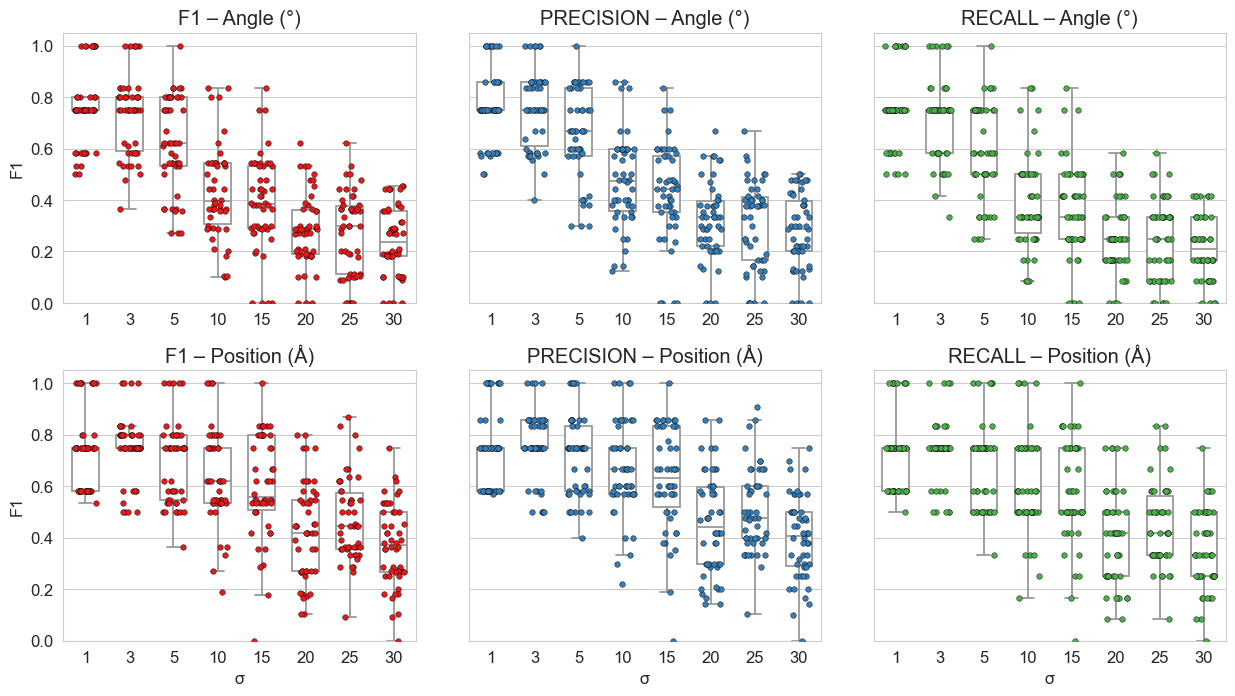

In [12]:
# requirements: pandas, numpy, matplotlib, seaborn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------------------------------ #
# 1.  LOAD DATA                                                      #
# ------------------------------------------------------------------ #
pos   = pd.read_csv('noise_sweep_metrics.csv')           # positional σ in Å
ang   = pd.read_csv('angle_noise_sweep_metrics.csv')     # angular    σ in °

pos['noise'] = pos['sigma']        ; pos['kind'] = 'Position (Å)'
ang['noise'] = ang['sigma (deg)']        ; ang['kind'] = 'Angle (°)'

df = pd.concat([pos, ang], ignore_index=True)

# ------------------------------------------------------------------ #
# 2.  NICE COLOURS & GLOBAL STYLE                                    #
# ------------------------------------------------------------------ #
sns.set_style('whitegrid')
metric_palette = dict(f1='#e41a1c', precision='#377eb8', recall='#4daf4a')

# ------------------------------------------------------------------ #
# 3.  HELPER FOR TEXT SUMMARY BELOW X-AXIS                           #
# ------------------------------------------------------------------ #
def add_summary(ax, data, x_pos):
    q25 = data.quantile(0.25)
    q75 = data.quantile(0.75)
    txt  = f"n={len(data)}\nmed={data.median():.2f}\niqr={q75-q25:.2f}"
    ax.text(x_pos, -0.15, txt,
            ha='center', va='top', fontsize=8, transform=ax.get_xaxis_transform())

# ------------------------------------------------------------------ #
# 4.  PLOT GRID                                                      #
# ------------------------------------------------------------------ #
fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharey='row')
metrics   = ['f1', 'precision', 'recall']

for row, (kind, sub) in enumerate(df.groupby('kind')):
    for col, metric in enumerate(metrics):
        ax = axes[row, col]

        sns.boxplot(x='noise', y=metric, data=sub,
                    ax=ax, width=.6, color='white', fliersize=0, linewidth=1.3)
        sns.stripplot(x='noise', y=metric, data=sub,
                      ax=ax, size=4, jitter=.25,
                      color=metric_palette[metric], edgecolor='k', linewidth=.3)

        ax.set_xlabel('σ' if row else '')      # only bottom row gets label
        ax.set_ylabel(metric.capitalize() if col==0 else '')
        ax.set_title(f"{metric.upper()} – {kind}")
        ax.set_ylim(0, 1.05)

        # summary text for each x-tick
        #for i, x_tick in enumerate(sorted(sub['noise'].unique())):
        #    add_summary(ax, sub.loc[sub['noise']==x_tick, metric], i)

# leave space for text under boxes
plt.subplots_adjust(hspace=.25, wspace=.15, bottom=.12)
plt.show()


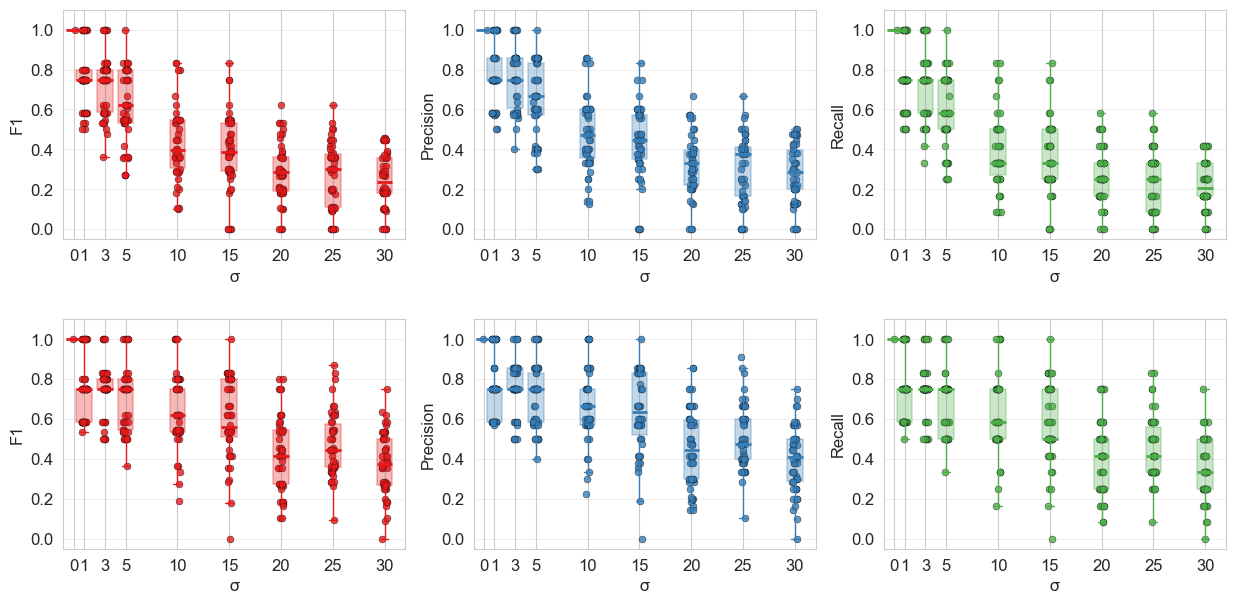

In [30]:
# requirements: pandas, numpy, matplotlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --------------------------------------------------------------- #
# 1.  READ + PATCH DATA                                           #
# --------------------------------------------------------------- #
def load_metrics(csv_path, kind_label):
    df = pd.read_csv(csv_path)
    # the σ column is sometimes called 'sigma', sometimes something else
    if 'sigma' not in df.columns:
        df = df.rename(columns={c: 'sigma' for c in df.columns
                                if c.lower().startswith('sigma') or
                                   c.lower().startswith('ang')})
    # inject perfect-score rows if 0 is missing
    if not (df['sigma'] == 0).any():
        perf = dict(sigma = 0, trial = 0,
                    precision = 1.0, recall = 1.0, f1 = 1.0)
        df = pd.concat([df, pd.DataFrame([perf])], ignore_index=True)
    df['kind'] = kind_label
    return df

pos = load_metrics('noise_sweep_metrics.csv',  'Position (Å)')
ang = load_metrics('angle_noise_sweep_metrics.csv', 'Angle (°)')
data = pd.concat([pos, ang], ignore_index=True)

# --------------------------------------------------------------- #
# 2.  BASIC PLOT SETTINGS                                         #
# --------------------------------------------------------------- #
metrics   = ['f1', 'precision', 'recall']
colors    = dict(f1='#e41a1c', precision='#377eb8', recall='#4daf4a')
jitter    = 0.25                     # horizontal scatter jitter

fig, axes = plt.subplots(2, 3, figsize=(15, 7), )
fig.subplots_adjust(hspace=0.35, wspace=0.2)

# --------------------------------------------------------------- #
# 3.  MAIN LOOP                                                   #
# --------------------------------------------------------------- #
for row, (kind, sub) in enumerate(data.groupby('kind')):
    xs_unique = np.sort(sub['sigma'].unique())
    for col, metric in enumerate(metrics):
        ax  = axes[row, col]

        # --- box-and-scatter for each σ --------------------------
        for sigma in xs_unique:
            ys = sub.loc[sub['sigma'] == sigma, metric].values

            # box
            ax.boxplot(ys, positions=[sigma], widths=1.5,
                       patch_artist=True, showfliers=False,
                       boxprops   = dict(facecolor=colors[metric], edgecolor=colors[metric], linewidth=1.2, alpha=.3),
                       medianprops= dict(color=colors[metric],    linewidth=2),
                       whiskerprops=dict(color=colors[metric]),
                       capprops    =dict(color=colors[metric]))

            # jittered points
            jittered_x = sigma + np.random.uniform(-jitter, jitter, size=len(ys))
            ax.scatter(jittered_x, ys, s=25, color=colors[metric],
                       edgecolor='k', linewidth=0.3, alpha=0.8)

            # summary text under each box
            #q1, q3 = np.percentile(ys, [25, 75])
            #txt = (f"n={len(ys)}\n"
            #       f"med={np.median(ys):.2f}\n"
            #       f"IQR={q3 - q1:.2f}")
            #ax.text(sigma, -0.13, txt, ha='center', va='top',
            #        transform=ax.get_xaxis_transform(), fontsize=7)

        # --- cosmetics ------------------------------------------
        #ax.set_title(f"{metric.upper()} – {kind}")
        ax.set_ylabel(metric.capitalize())
        ax.set_xlabel('σ')
        #else:
        #    ax.set_xlabel('')
        ax.set_xticks(xs_unique)
        ax.set_ylim(-.05, 1.1)
        ax.set_xlim(-1, 32)
        ax.grid(axis='y', alpha=0.3)

plt.show()

fig.savefig('../../../../../../../../Papers/Chromatin_3D_Remodeling_Upon_T-Cell_Activation/Revisions/Figures/Images/Robustness_EMD2601_v1_Revision.pdf', bbox_inches='tight')